In [1]:
import numpy as np 
import pandas as pd 
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt 
import seaborn as sns 


In [2]:
from sklearn.datasets import load_iris
import torch

iris = load_iris()

X = torch.tensor(iris.data, dtype=torch.float32)
y = torch.tensor(iris.target, dtype=torch.long)

In [3]:
model=nn.Sequential(
    nn.Linear(4,1),
    nn.ReLU(),
    nn.Linear(1 ,3),
   
)

In [4]:
learning_rate=0.01
lossfun=nn.CrossEntropyLoss()
solver=torch.optim.Adam(model.parameters(),lr=learning_rate)


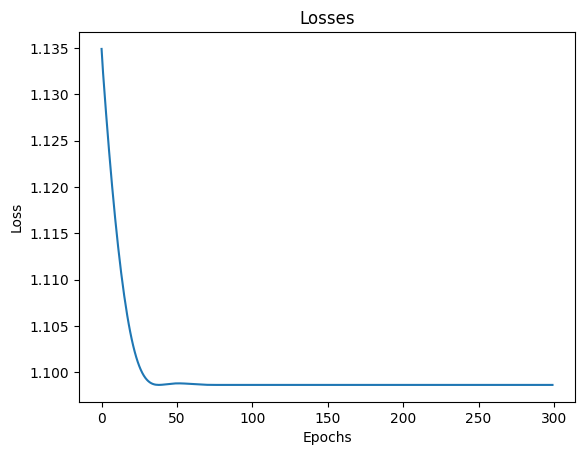

In [5]:
#model training 
losses=[]
for i in range(1 , 301):
    #forward prop 
    y_preds=model(X)
    
    #loss 
    loss=lossfun(y_preds , y)
    losses.append(loss.item())
    #back prop 
    solver.zero_grad() #this is important to prevent accumulation of gradients
    loss.backward()
    solver.step() #this is where the weights are updated
    
    
 #plotting the losses 
sns.lineplot(x=range(len(losses)), y=losses)
plt.title('Losses')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [6]:
#accuracy 
y_preds = model(X)

y_pred_classes = torch.argmax(y_preds, dim=1)

from sklearn.metrics import classification_report , accuracy_score

print(classification_report(y.detach().numpy(),y_pred_classes.detach().numpy()))
print(accuracy_score(y.detach().numpy(),y_pred_classes.detach().numpy()))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.00      0.00      0.00        50
           2       0.33      1.00      0.50        50

    accuracy                           0.33       150
   macro avg       0.11      0.33      0.17       150
weighted avg       0.11      0.33      0.17       150

0.3333333333333333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Now we will differ the width of the neural network and see how the number of hidden layers effect 


In [7]:
def Nhidden(n):

    model = nn.Sequential(
        nn.Linear(4, n),
        nn.ReLU(),
        nn.Linear(n, n),
        nn.ReLU(),
        nn.Linear(n,3)
    )

    learning_rate = 0.01
    lossfun = nn.CrossEntropyLoss()
    solver = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for i in range(1,301):

        y_preds = model(X)

        loss = lossfun(y_preds, y)

        solver.zero_grad()
        loss.backward()
        solver.step()

    y_preds = model(X)
    y_pred_classes = torch.argmax(y_preds, dim=1)

    from sklearn.metrics import accuracy_score

    accuracy = accuracy_score(y.detach().numpy(),
                              y_pred_classes.detach().numpy())

    return accuracy

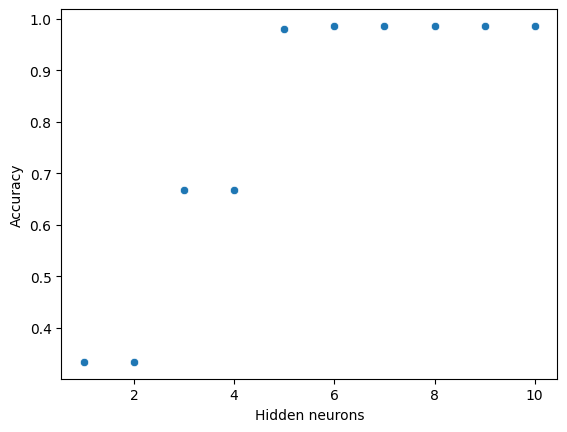

In [8]:
accuracy = []

for n in range(1,11):
    accuracy.append(Nhidden(n))

plt.figure()
sns.scatterplot(x=range(1,11), y=accuracy)
plt.xlabel("Hidden neurons")
plt.ylabel("Accuracy")
plt.show()

The scatter plot shows how the classification accuracy changes as the number of hidden neurons increases from 1 to 10.


When the number of hidden neurons is 1 or 2, the accuracy is very low (~0.33).
This occurs because the neural network has very limited capacity and cannot learn the complex relationships in the dataset. This situation is known as underfitting.


When the number of hidden neurons increases to 3 or more, the accuracy rises sharply to around 0.98–1.0.
At this point, the model has sufficient representational capacity to capture the patterns in the data.


After about 3–4 hidden neurons, the accuracy remains almost constant.
This indicates that adding more neurons does not significantly improve performance, because the model has already learned the underlying structure of the dataset.


Conclusion

The experiment demonstrates that:

Increasing hidden neurons initially improves model performance.

After a certain point, accuracy saturates, meaning additional neurons provide little or no improvement.

Therefore, a small number of hidden neurons (around 3–4) is sufficient for achieving high accuracy on this dataset.